In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import cv2
import seaborn as sns

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import models, layers, Sequential
from keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
DATASET_PATH = "../clahe_dataset"
EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)

SAVED_MODEL = "cnn_weighted_model.h5"
# CLASSES = [d for d in os.listdir(TRAIN_DATA_PATH) if d != '.DS_Store']

In [3]:
def apply_clahe(img):
    img = img.astype(np.uint8)

    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)

    lab = cv2.merge((l, a, b))
    img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return img


def process_and_save_clahe(input_root, output_root, img_size=(96,96)):
    for split in ["Train"]:
        split_path = os.path.join(input_root, split)

        for class_name in os.listdir(split_path):
            class_path = os.path.join(split_path, class_name)

            if not os.path.isdir(class_path):
                continue

            save_class_path = os.path.join(output_root, split, class_name)
            os.makedirs(save_class_path, exist_ok=True)

            for img_name in os.listdir(class_path):
                if img_name.startswith("."):
                    continue

                img_path = os.path.join(class_path, img_name)

                img = cv2.imread(img_path)
                if img is None:
                    continue

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, img_size)

                img = apply_clahe(img)

                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

                save_path = os.path.join(save_class_path, img_name)
                cv2.imwrite(save_path, img)

    print("CLAHE train dataset saved!")

In [4]:
# process_and_save_clahe(DATASET_PATH, "../clahe_dataset", img_size=IMG_SIZE)

In [5]:
TRAIN_CLAHE_DATA_PATH = "../clahe_dataset/Train"

In [6]:
# # return float32 not uint8
# def apply_clahe(img):
#     img = img.astype('uint8')
#     lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
#     l, a, b = cv2.split(lab)

#     clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
#     l = clahe.apply(l)

#     lab = cv2.merge((l, a, b))
#     img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


#     return img.astype('float32')

In [7]:
# CLAHE виконується під час кожного проходу генератора (повтор кожного epoch)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
)

In [8]:

train_dataset = train_datagen.flow_from_directory(
    TRAIN_DATA_PATH,
    subset="training",
    seed = RANDOM_SEED,
    target_size=IMG_SIZE,
    color_mode="rgb",
    class_mode = "categorical"
)

val_dataset = train_datagen.flow_from_directory(
    TRAIN_DATA_PATH,
    seed = RANDOM_SEED,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    class_mode = "categorical",
    subset="validation"
)

test_dataset = test_datagen.flow_from_directory(
    TEST_DATA_PATH,
    target_size=IMG_SIZE,
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_mode = "categorical"
)

Found 12890 images belonging to 8 classes.
Found 3218 images belonging to 8 classes.
Found 14518 images belonging to 8 classes.


In [9]:
train_counts = {}
CLASSES = list(train_dataset.class_indices.keys())

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)

{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


In [10]:
train_counts = {}
CLASSES = list(train_dataset.class_indices.keys())

for cls in CLASSES:
    cls_folder = os.path.join(TRAIN_CLAHE_DATA_PATH, cls)
    train_counts[cls] = len(os.listdir(cls_folder))

print(train_counts)


{'anger': 1500, 'contempt': 1559, 'disgust': 1229, 'fear': 1512, 'happy': 2340, 'neutral': 2758, 'sad': 3091, 'surprise': 2119}


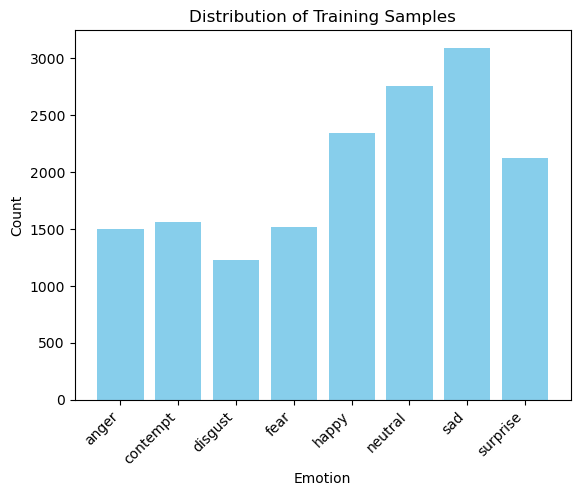

In [11]:
plt.bar(train_counts.keys(), train_counts.values(), color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.title('Distribution of Training Samples')
plt.show()

In [12]:
# Calculate class weights for imbalanced dataset
# Create label list manually from folder counts
labels = []

for idx, cls in enumerate(CLASSES):
    count = train_counts[cls]
    labels.extend([idx] * count)

labels = np.array(labels)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(zip(range(len(class_weights_array)), class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.3423333333333334), 1: np.float64(1.2915330339961513), 2: np.float64(1.6383238405207485), 3: np.float64(1.3316798941798942), 4: np.float64(0.8604700854700855), 5: np.float64(0.7300580130529369), 6: np.float64(0.6514073115496603), 7: np.float64(0.9502123643227938)}


In [13]:
# labels = train_dataset.classes
# class_weights_array = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(labels),
#     y=labels
# )
# class_weights = dict(enumerate(class_weights_array))
# print("Class weights:", class_weights)

In [14]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [15]:
model = tf.keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    # Rescaling layer to normalize pixel values to [0, 1] for CNN better performance
    # Rescaling is not needed if using a pretrained model that expects 0-255 input, but since we're building from scratch, it's beneficial to normalize the input.
    # Input normalization can help the model converge faster and improve performance.

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # layers.Flatten(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(8, activation='softmax')
])
model.compile(loss='categorical_crossentropy', optimizer=AdamW(), metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 158,760 (620.16 KB)

 Trainable params: 157,864 (616.66 KB)

 Non-trainable params: 896 (3.50 KB)

In [16]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
mc = ModelCheckpoint(SAVED_MODEL, monitor='val_accuracy', save_best_only=True)
csv_logger = CSVLogger('cnn_weighted_loss_training_log.csv')
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,    
    min_lr=1e-6
)

In [17]:
start = time.time()
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[es, mc, csv_logger, rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.1410 - loss: 2.3494

403/403 ━━━━━━━━━━━━━━━━━━━━ 73s 177ms/step - accuracy: 0.1437 - loss: 2.2688 - val_accuracy: 0.1566 - val_loss: 2.1732 - learning_rate: 0.0010
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.1505 - loss: 2.1783

403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.1625 - loss: 2.1535 - val_accuracy: 0.1774 - val_loss: 2.0527 - learning_rate: 0.0010
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 175ms/step - accuracy: 0.1867 - loss: 2.0678 - val_accuracy: 0.1013 - val_loss: 2.4532 - learning_rate: 0.0010
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2006 - loss: 2.0092

403/403 ━━━━━━━━━━━━━━━━━━━━ 69s 171ms/step - accuracy: 0.2080 - loss: 1.9944 - val_accuracy: 0.2001 - val_loss: 1.9508 - learning_rate: 0.0010
Epoch 5/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2305 - loss: 1.9235

403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 178ms/step - accuracy: 0.2396 - loss: 1.8844 - val_accuracy: 0.2530 - val_loss: 1.6801 - learning_rate: 0.0010
Epoch 6/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.2692 - loss: 1.7471 - val_accuracy: 0.1535 - val_loss: 2.3080 - learning_rate: 0.0010
Epoch 7/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2881 - loss: 1.6917

...

403/403 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.4884 - loss: 1.3100 - val_accuracy: 0.5056 - val_loss: 1.1883 - learning_rate: 2.7000e-05
Epoch 41/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.4878 - loss: 1.3187 - val_accuracy: 0.5044 - val_loss: 1.1848 - learning_rate: 2.7000e-05
Epoch 42/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.4919 - loss: 1.3043 - val_accuracy: 0.5025 - val_loss: 1.1919 - learning_rate: 2.7000e-05
Epoch 43/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.4867 - loss: 1.2931

403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.4885 - loss: 1.3041 - val_accuracy: 0.5075 - val_loss: 1.1826 - learning_rate: 2.7000e-05
Epoch 44/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.4956 - loss: 1.2914

403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.4919 - loss: 1.3001 - val_accuracy: 0.5099 - val_loss: 1.1835 - learning_rate: 2.7000e-05
Epoch 45/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.4850 - loss: 1.3079 - val_accuracy: 0.5025 - val_loss: 1.1933 - learning_rate: 2.7000e-05
Epoch 46/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.4962 - loss: 1.3069 - val_accuracy: 0.5096 - val_loss: 1.1864 - learning_rate: 2.7000e-05
Epoch 47/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 175ms/step - accuracy: 0.4900 - loss: 1.3099 - val_accuracy: 0.5056 - val_loss: 1.1924 - learning_rate: 8.1000e-06
Epoch 48/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 179ms/step - accuracy: 0.4953 - loss: 1.3003 - val_accuracy: 0.5068 - val_loss: 1.1833 - learning_rate: 8.1000e-06
Epoch 49/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4972 - loss: 1.2950

403/403 ━━━━━━━━━━━━━━━━━━━━ 69s 170ms/step - accuracy: 0.4996 - loss: 1.3002 - val_accuracy: 0.5109 - val_loss: 1.1821 - learning_rate: 8.1000e-06
Epoch 50/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 180ms/step - accuracy: 0.4954 - loss: 1.3044 - val_accuracy: 0.5040 - val_loss: 1.1886 - learning_rate: 8.1000e-06
Epoch 51/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 73s 180ms/step - accuracy: 0.4937 - loss: 1.3002 - val_accuracy: 0.5090 - val_loss: 1.1848 - learning_rate: 8.1000e-06
Epoch 52/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step - accuracy: 0.4894 - loss: 1.3008 - val_accuracy: 0.5090 - val_loss: 1.1814 - learning_rate: 8.1000e-06
Epoch 53/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.4874 - loss: 1.3036

403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.4956 - loss: 1.2981 - val_accuracy: 0.5134 - val_loss: 1.1801 - learning_rate: 8.1000e-06
Epoch 54/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 177ms/step - accuracy: 0.4901 - loss: 1.2972 - val_accuracy: 0.5081 - val_loss: 1.1834 - learning_rate: 8.1000e-06
Epoch 55/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 175ms/step - accuracy: 0.4971 - loss: 1.2972 - val_accuracy: 0.5071 - val_loss: 1.1890 - learning_rate: 8.1000e-06
Epoch 56/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 71s 176ms/step - accuracy: 0.4910 - loss: 1.2993 - val_accuracy: 0.5115 - val_loss: 1.1792 - learning_rate: 8.1000e-06
Epoch 57/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.4914 - loss: 1.3047 - val_accuracy: 0.5115 - val_loss: 1.1805 - learning_rate: 8.1000e-06
Epoch 58/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 72s 177ms/step - accuracy: 0.4927 - loss: 1.2956 - val_accuracy: 0.5124 - val_loss: 1.1816 - learning_rate: 8.1000e-06
Epoch 59/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 73s 1

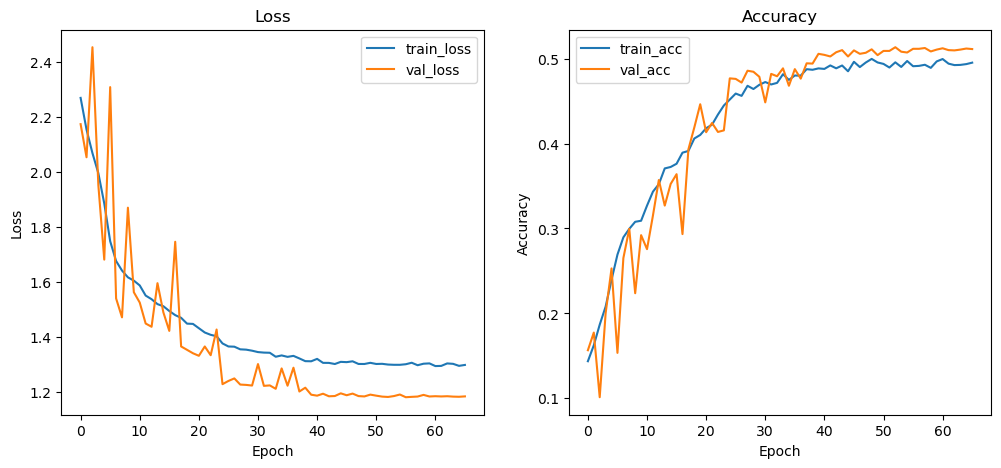

In [19]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [20]:
model = tf.keras.models.load_model(SAVED_MODEL)

In [21]:
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc*100:.2f}%")

454/454 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.4945 - loss: 2.1936
Test Accuracy: 49.45%


Evaluating on Test Set...
454/454 ━━━━━━━━━━━━━━━━━━━━ 16s 36ms/step - accuracy: 0.4945 - loss: 2.1936
Test Accuracy: 49.45%
Generating predictions...
454/454 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step

Classification Report:

              precision    recall  f1-score   support

       anger       0.39      0.53      0.45      1718
    contempt       0.39      0.55      0.46      1312
     disgust       0.39      0.06      0.11      1248
        fear       0.60      0.14      0.22      1664
       happy       0.87      0.62      0.73      2704
     neutral       0.56      0.93      0.70      2368
         sad       0.35      0.33      0.34      1584
    surprise       0.34      0.44      0.39      1920

    accuracy                           0.49     14518
   macro avg       0.49      0.45      0.42     14518
weighted avg       0.52      0.49      0.47     14518



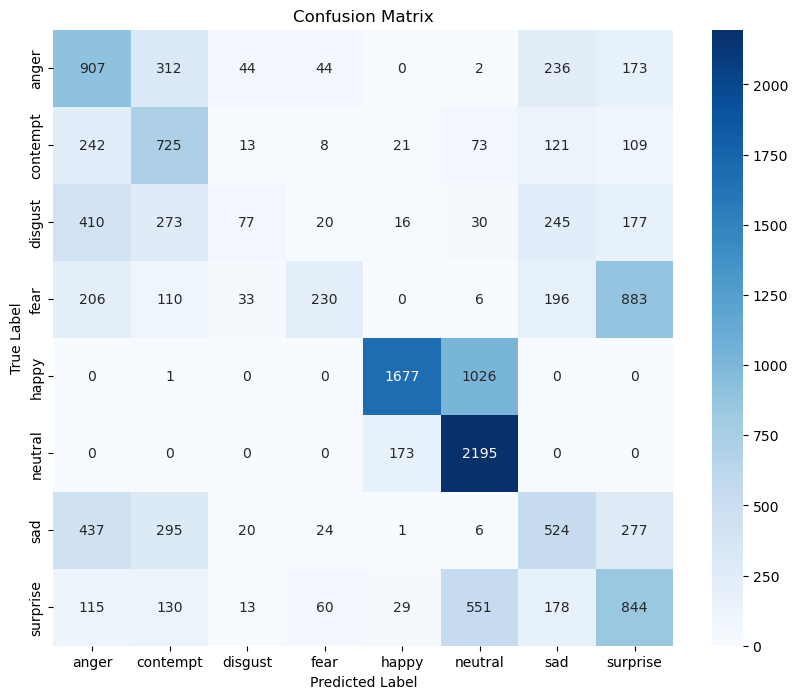

In [22]:
def report_test_results():
    print("Evaluating on Test Set...")
    # Evaluate returns [loss, accuracy]
    loss, accuracy = model.evaluate(test_dataset)
    print(f"Test Accuracy: {accuracy*100:.2f}%")

    # Make predictions
    print("Generating predictions...")
    predictions = model.predict(test_dataset, verbose=1)

    # Convert predictions to class indexes
    y_pred_indices = np.argmax(predictions, axis=1)

    # Get true labels directly from the generator
    y_true_indices = test_dataset.classes

    # Get the class names (labels)
    class_labels = list(test_dataset.class_indices.keys())

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true_indices, y_pred_indices, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true_indices, y_pred_indices)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

# Call the function
report_test_results()

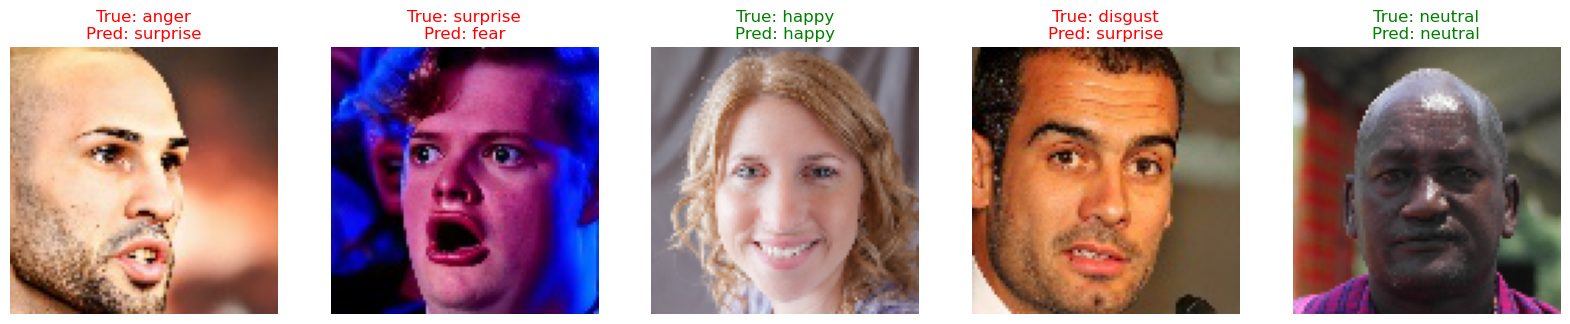

In [ ]:
def predict_random_samples():
    # Grab a single batch of images
    # We use next() to fetch the first batch from the generator
    images, labels = next(test_dataset)

    # Pick 5 random indices from this batch (batch size is usually 32)
    indices = np.random.choice(len(images), 5, replace=False)

    # Get class names map {0: 'angry', 1: 'happy', ...}
    # class_map = {v: k for k, v in val_dataset.class_indices.items()}

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for i, idx in enumerate(indices):
        img = images[idx]

        # Get True Label
        true_idx = np.argmax(labels[idx])
        true_label = CLASSES[true_idx]

        # Get Prediction
        # Add extra dim because model expects (Batch, Height, Width, Channel)
        pred_prob = model.predict(np.expand_dims(img, axis=0), verbose=0)
        pred_idx = np.argmax(pred_prob)
        pred_label = CLASSES[pred_idx]

        # Display Image
        # Squeeze removes the channel dim (96,96,3) -> (96,96) for plotting
        axes[i].imshow(img.squeeze())
        axes[i].axis('off')

        # Title color: Green if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color)

    plt.show()

predict_random_samples()